### IMPORTS

In [3]:

import os
import gc
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    top_k_accuracy_score
)
from sklearn.preprocessing import label_binarize

In [4]:
print(os.listdir("/kaggle/input/datasets/shanthoshkumarr/gf-jfc-final/face_crops"))

['Face2Face', 'Deepfakes', 'DeepFakeDetection', 'original', 'NeuralTextures', 'FaceShifter', 'FaceSwap']


### config

In [5]:


# =========================
# CONFIG
# =========================
DATA_PATH   = "/kaggle/input/datasets/shanthoshkumarr/gf-jfc-final/face_crops"
BATCH_SIZE  = 32
EPOCHS      = 15
LR          = 2e-4
PATIENCE    = 2
IMG_SIZE    = 224
SEED        = 42
NUM_CLASSES = 7

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CLASS_NAMES = [
    "DeepFakeDetection",
    "Deepfakes",
    "Face2Face",
    "FaceShifter",
    "FaceSwap",
    "NeuralTextures",
    "original"
]

CLASS_TO_IDX = {cls_name: idx for idx, cls_name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {idx: cls_name for cls_name, idx in CLASS_TO_IDX.items()}

torch.cuda.empty_cache()
gc.collect()

print("=" * 70)
print("DEEPFAKE DETECTION — 7 CLASS MULTICLASS CLASSIFICATION")
print("=" * 70)
print(f"Device       : {DEVICE}")
print(f"Batch Size   : {BATCH_SIZE}")
print(f"Epochs       : {EPOCHS}")
print(f"LR           : {LR}")
print(f"Num Classes  : {NUM_CLASSES}")
print(f"Dataset Path : {DATA_PATH}")

DEEPFAKE DETECTION — 7 CLASS MULTICLASS CLASSIFICATION
Device       : cuda
Batch Size   : 32
Epochs       : 15
LR           : 0.0002
Num Classes  : 7
Dataset Path : /kaggle/input/datasets/shanthoshkumarr/gf-jfc-final/face_crops


### collect image paths


In [6]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
print("Random seed fixed.")

Random seed fixed.


In [7]:
IMG_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

def collect_image_paths(data_path, class_names):
    samples = []

    for class_name in class_names:
        class_dir = os.path.join(data_path, class_name)

        if not os.path.exists(class_dir):
            print(f"[WARNING] Missing class folder: {class_dir}")
            continue

        for root, _, files in os.walk(class_dir):
            for file in files:
                if file.lower().endswith(IMG_EXTENSIONS):
                    img_path = os.path.join(root, file)
                    label = CLASS_TO_IDX[class_name]
                    samples.append((img_path, label, class_name))

    return samples


samples = collect_image_paths(DATA_PATH, CLASS_NAMES)
df = pd.DataFrame(samples, columns=["image_path", "label", "class_name"])

print(f"Total images found: {len(df)}")
print("\nClass distribution:")
print(df["class_name"].value_counts().sort_index())
df.head()

Total images found: 40984

Class distribution:
class_name
DeepFakeDetection    5198
Deepfakes            5346
Face2Face            7025
FaceShifter          7004
FaceSwap             5515
NeuralTextures       5539
original             5357
Name: count, dtype: int64


,image_path,label,class_name
0,/kaggle/input/datasets/shanthoshkumarr/gf-jfc-...,0,DeepFakeDetection
1,/kaggle/input/datasets/shanthoshkumarr/gf-jfc-...,0,DeepFakeDetection
2,/kaggle/input/datasets/shanthoshkumarr/gf-jfc-...,0,DeepFakeDetection
3,/kaggle/input/datasets/shanthoshkumarr/gf-jfc-...,0,DeepFakeDetection
4,/kaggle/input/datasets/shanthoshkumarr/gf-jfc-...,0,DeepFakeDetection


### dataset split

In [8]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print("Split sizes:")
print(f"Train : {len(train_df)}")
print(f"Val   : {len(val_df)}")
print(f"Test  : {len(test_df)}")

print("\nTrain distribution:")
print(train_df["class_name"].value_counts().sort_index())

print("\nVal distribution:")
print(val_df["class_name"].value_counts().sort_index())

print("\nTest distribution:")
print(test_df["class_name"].value_counts().sort_index())

Split sizes:
Train : 32787
Val   : 4098
Test  : 4099

Train distribution:
class_name
DeepFakeDetection    4158
Deepfakes            4277
Face2Face            5620
FaceShifter          5603
FaceSwap             4412
NeuralTextures       4431
original             4286
Name: count, dtype: int64

Val distribution:
class_name
DeepFakeDetection    520
Deepfakes            535
Face2Face            702
FaceShifter          700
FaceSwap             551
NeuralTextures       554
original             536
Name: count, dtype: int64

Test distribution:
class_name
DeepFakeDetection    520
Deepfakes            534
Face2Face            703
FaceShifter          701
FaceSwap             552
NeuralTextures       554
original             535
Name: count, dtype: int64


### transforms

In [9]:
class DeepfakeFrameDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = row["image_path"]
        label = int(row["label"])

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

### dataset class

In [10]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

### dataloaders

In [11]:
train_dataset = DeepfakeFrameDataset(train_df, transform=train_transform)
val_dataset   = DeepfakeFrameDataset(val_df, transform=eval_transform)
test_dataset  = DeepfakeFrameDataset(test_df, transform=eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders ready.")

DataLoaders ready.


In [12]:
images, labels = next(iter(train_loader))
print("Batch image shape :", images.shape)
print("Batch labels shape:", labels.shape)
print("Sample labels     :", labels[:10].tolist())

Batch image shape : torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Sample labels     : [1, 2, 3, 2, 3, 2, 0, 2, 0, 4]


### model

In [13]:
import torch
import torch.nn as nn
import torchvision.models as models
import gc

print("\nBuilding 5-expert model...")


# =========================
# Cross Attention Fusion
# =========================
class CrossAttentionFusion(nn.Module):
    def __init__(self, dim=256, num_experts=5, heads=4):
        super().__init__()

        self.gate = nn.Sequential(
            nn.Linear(dim * num_experts, num_experts),
            nn.Softmax(dim=-1)
        )

        self.q = nn.Linear(dim, dim)
        self.k = nn.Linear(dim, dim)
        self.v = nn.Linear(dim, dim)

        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=heads,
            dropout=0.1,
            batch_first=True
        )

        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)

        self.ffn = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(dim * 2, dim)
        )

    def forward(self, feats):
        # feats: list of [B, D]
        x = torch.stack(feats, dim=1)   # [B, N, D]
        B, N, D = x.shape

        gate_w = self.gate(x.reshape(B, N * D))   # [B, N]
        xg = x * gate_w.unsqueeze(-1)             # [B, N, D]

        q = self.q(xg.mean(dim=1, keepdim=True))  # [B, 1, D]
        k = self.k(xg)
        v = self.v(xg)

        out, _ = self.attn(q, k, v)
        out = out.squeeze(1)
        q = q.squeeze(1)

        fused = self.norm1(out + q)
        fused = self.norm2(fused + self.ffn(fused))

        return fused, gate_w


# =========================
# 5-Expert Model
# =========================
class DeepfakeDetector5Experts(nn.Module):
    def __init__(self, dim, num_classes):
        super().__init__()

        # -------- Expert 1 — EfficientNet-B0 --------
        e1 = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.DEFAULT
        )
        e1.classifier = nn.Identity()
        self.expert1 = e1   # 1280

        # -------- Expert 2 — ResNet18 --------
        e2 = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT
        )
        e2.fc = nn.Identity()
        self.expert2 = e2   # 512

        # -------- Expert 3 — MobileNetV3 --------
        e3 = models.mobilenet_v3_small(
            weights=models.MobileNet_V3_Small_Weights.DEFAULT
        )
        e3.classifier = nn.Identity()
        self.expert3 = e3   # 576

        # -------- Expert 4 — EfficientNet-B3 --------
        e4 = models.efficientnet_b3(
            weights=models.EfficientNet_B3_Weights.DEFAULT
        )
        e4.classifier = nn.Identity()
        self.expert4 = e4   # 1536

        # -------- Expert 5 — ConvNeXt-Tiny (FIXED) --------
        e5 = models.convnext_tiny(
            weights=models.ConvNeXt_Tiny_Weights.DEFAULT
        )

        # Replace classifier AND ensure flattening
        self.expert5 = nn.Sequential(
            e5.features,
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten()   # -> [B, 768]
        )

        # =========================
        # Freeze all first
        # =========================
        for e in [self.expert1, self.expert2, self.expert3, self.expert4]:
            for p in e.parameters():
                p.requires_grad = False

        for p in self.expert5.parameters():
            p.requires_grad = False

        # =========================
        # Unfreeze last blocks
        # =========================
        for p in self.expert1.features[-3:].parameters():
            p.requires_grad = True

        for p in self.expert2.layer4.parameters():
            p.requires_grad = True

        for p in self.expert3.features[-3:].parameters():
            p.requires_grad = True

        for p in self.expert4.features[-3:].parameters():
            p.requires_grad = True

        # ConvNeXt last block
        for p in self.expert5[0][-1].parameters():
            p.requires_grad = True

        # =========================
        # Projection heads
        # =========================
        self.p1 = nn.Linear(1280, dim)
        self.p2 = nn.Linear(512, dim)
        self.p3 = nn.Linear(576, dim)
        self.p4 = nn.Linear(1536, dim)
        self.p5 = nn.Linear(768, dim)

        # =========================
        # Fusion
        # =========================
        self.fusion = CrossAttentionFusion(dim=dim, num_experts=5, heads=4)

        # =========================
        # Classifier
        # =========================
        self.clf = nn.Sequential(
            nn.Linear(dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        f1 = self.p1(self.expert1(x).float())
        f2 = self.p2(self.expert2(x).float())
        f3 = self.p3(self.expert3(x).float())
        f4 = self.p4(self.expert4(x).float())
        f5 = self.p5(self.expert5(x).float())  # FIXED

        # Optional debug (remove later)
        # print(f1.shape, f2.shape, f3.shape, f4.shape, f5.shape)

        fused, gate_w = self.fusion([f1, f2, f3, f4, f5])
        logits = self.clf(fused)

        return logits, gate_w


# =========================
# Test Run
# =========================
model = DeepfakeDetector5Experts(256, NUM_CLASSES).to(DEVICE)

dummy = torch.randn(4, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
out, gate = model(dummy)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print("5-expert model ready")
print("Output shape :", out.shape)
print("Gate shape   :", gate.shape)
print(f"Trainable    : {trainable:,}")
print(f"Total params : {total:,}")

del dummy
torch.cuda.empty_cache()
gc.collect()


Building 5-expert model...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 138MB/s] 


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 177MB/s] 


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


...

100%|██████████| 47.2M/47.2M [00:00<00:00, 193MB/s]


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 187MB/s]  


5-expert model ready
Output shape : torch.Size([4, 7])
Gate shape   : torch.Size([4, 5])
Trainable    : 36,959,782
Total params : 56,596,080


30

### criterion / optimizer / scheduler

In [14]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)
scaler = torch.cuda.amp.GradScaler()

os.makedirs("/kaggle/working/models", exist_ok=True)

print("Training objects ready.")

Training objects ready.


### train loop

In [15]:
from tqdm import tqdm

def train_epoch(model, loader, optimizer, criterion, epoch):
    model.train()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    progress_bar = tqdm(loader, desc=f"Epoch {epoch} [Train]", leave=False)

    for batch_idx, (x, y) in enumerate(progress_bar):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        logits, _ = model(x)
        loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(y.detach().cpu().numpy())

        # 🔥 LIVE UPDATE
        progress_bar.set_postfix({
            "loss": f"{loss.item():.4f}"
        })

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return avg_loss, acc, f1_macro

    


@torch.no_grad()
def get_predictions_and_probs(model, loader):
    model.eval()

    all_probs = []
    all_preds = []
    all_labels = []

    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)

        # ❌ DO NOT use autocast here (causes NaNs in eval sometimes)
        logits, _ = model(x)

        # 🚨 Check logits
        if torch.isnan(logits).any():
            print("⚠️ NaNs in logits - skipping batch")
            continue

        # ✅ Stable softmax (convert to float32 BEFORE softmax)
        probs = torch.softmax(logits.float(), dim=1)

        # 🚨 Fix any NaNs AFTER softmax
        probs = torch.nan_to_num(probs, nan=0.0, posinf=1.0, neginf=0.0)

        preds = torch.argmax(probs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    return all_probs, all_preds, all_labels


def multiclass_auc(labels, probs, num_classes):
    import numpy as np
    from sklearn.preprocessing import label_binarize
    from sklearn.metrics import roc_auc_score

    labels = np.array(labels)
    probs = np.array(probs)

    # 🚨 Fix NaNs / infs
    probs = np.nan_to_num(probs, nan=0.0, posinf=1.0, neginf=0.0)

    # 🚨 Clip values
    probs = np.clip(probs, 1e-7, 1 - 1e-7)

    # 🚨 Normalize rows
    row_sums = probs.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    probs = probs / row_sums

    y_bin = label_binarize(labels, classes=list(range(num_classes)))

    try:
        auc_macro = roc_auc_score(
            y_bin, probs,
            average="macro",
            multi_class="ovr"
        )

        auc_weighted = roc_auc_score(
            y_bin, probs,
            average="weighted",
            multi_class="ovr"
        )

    except ValueError as e:
        print("⚠️ AUC failed:", e)
        return 0.0, 0.0

    return auc_macro, auc_weighted

In [16]:
print("\nTraining...")
print("=" * 70)

best_val_auc = 0.0
patience_cnt = 0
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc, train_f1 = train_epoch(
        model, train_loader, optimizer, criterion,epoch
    )

    val_probs, val_preds, val_labels = get_predictions_and_probs(model, val_loader)
    val_acc = accuracy_score(val_labels, val_preds)
    val_f1_macro = f1_score(val_labels, val_preds, average="macro", zero_division=0)
    val_f1_weighted = f1_score(val_labels, val_preds, average="weighted", zero_division=0)
    val_auc_macro, val_auc_weighted = multiclass_auc(val_labels, val_probs, NUM_CLASSES)

    scheduler.step()

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_f1_macro": train_f1,
        "val_acc": val_acc,
        "val_f1_macro": val_f1_macro,
        "val_f1_weighted": val_f1_weighted,
        "val_auc_macro": val_auc_macro,
        "val_auc_weighted": val_auc_weighted
    })

    print(f"\nEpoch {epoch:02d}/{EPOCHS}")
    print(f"Train -> Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1(macro): {train_f1:.4f}")
    print(f"Val   -> Acc : {val_acc:.4f} | F1(macro): {val_f1_macro:.4f} | "
          f"F1(weighted): {val_f1_weighted:.4f} | AUC(macro): {val_auc_macro:.4f}")

    if val_auc_macro > best_val_auc:
        best_val_auc = val_auc_macro
        patience_cnt = 0

        torch.save({
            "model_state": model.state_dict(),
            "val_auc_macro": val_auc_macro,
            "class_names": CLASS_NAMES
        }, "/kaggle/working/models/best_model_multiclass.pth")

        print(f"Saved best model! Val AUC(macro): {best_val_auc:.4f}")
    else:
        patience_cnt += 1
        print(f"No improvement ({patience_cnt}/{PATIENCE})")

        if patience_cnt >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch}")
            break

print("\nTraining complete.")
print(f"Best Validation AUC (macro): {best_val_auc:.4f}")


Training...



Epoch 01/15
Train -> Loss: 1.2566 | Acc: 0.6304 | F1(macro): 0.6152
Val   -> Acc : 0.8123 | F1(macro): 0.8085 | F1(weighted): 0.8111 | AUC(macro): 0.9720
Saved best model! Val AUC(macro): 0.9720



Epoch 02/15
Train -> Loss: 0.8733 | Acc: 0.8265 | F1(macro): 0.8226
Val   -> Acc : 0.8870 | F1(macro): 0.8810 | F1(weighted): 0.8839 | AUC(macro): 0.9863
Saved best model! Val AUC(macro): 0.9863



Epoch 03/15
Train -> Loss: 0.7851 | Acc: 0.8661 | F1(macro): 0.8630
Val   -> Acc : 0.8936 | F1(macro): 0.8931 | F1(weighted): 0.8949 | AUC(macro): 0.9903
Saved best model! Val AUC(macro): 0.9903



Epoch 04/15
Train -> Loss: 0.7271 | Acc: 0.8928 | F1(macro): 0.8908
Val   -> Acc : 0.9244 | F1(macro): 0.9237 | F1(weighted): 0.9256 | AUC(macro): 0.9933
Saved best model! Val AUC(macro): 0.9933


...


Epoch 11/15
Train -> Loss: 0.5621 | Acc: 0.9660 | F1(macro): 0.9652
Val   -> Acc : 0.9534 | F1(macro): 0.9523 | F1(weighted): 0.9539 | AUC(macro): 0.9973
Saved best model! Val AUC(macro): 0.9973



Epoch 12/15
Train -> Loss: 0.5496 | Acc: 0.9701 | F1(macro): 0.9694
Val   -> Acc : 0.9597 | F1(macro): 0.9586 | F1(weighted): 0.9599 | AUC(macro): 0.9975
Saved best model! Val AUC(macro): 0.9975



Epoch 13/15
Train -> Loss: 0.5415 | Acc: 0.9735 | F1(macro): 0.9728
Val   -> Acc : 0.9583 | F1(macro): 0.9572 | F1(weighted): 0.9586 | AUC(macro): 0.9976
Saved best model! Val AUC(macro): 0.9976



Epoch 14/15
Train -> Loss: 0.5348 | Acc: 0.9773 | F1(macro): 0.9768
Val   -> Acc : 0.9583 | F1(macro): 0.9570 | F1(weighted): 0.9583 | AUC(macro): 0.9976
No improvement (1/2)



Epoch 15/15
Train -> Loss: 0.5321 | Acc: 0.9789 | F1(macro): 0.9783
Val   -> Acc : 0.9583 | F1(macro): 0.9572 | F1(weighted): 0.9585 | AUC(macro): 0.9976
Saved best model! Val AUC(macro): 0.9976

Training complete.
Best Validation AUC (macro): 0.9976


### validation and evaluation

In [17]:
history_df = pd.DataFrame(history)
history_df

,epoch,train_loss,train_acc,train_f1_macro,val_acc,val_f1_macro,val_f1_weighted,val_auc_macro,val_auc_weighted
0,1,1.256629,0.630372,0.615240,0.812347,0.808512,0.811089,0.972024,0.972983
1,2,0.873344,0.826456,0.822597,0.887018,0.881003,0.883874,0.986345,0.986980
2,3,0.785075,0.866075,0.863041,0.893607,0.893083,0.894889,0.990342,0.990752
3,4,0.727138,0.892793,0.890801,0.924353,0.923739,0.925566,0.993339,0.993651
4,5,0.688577,0.910361,0.908360,0.928014,0.927209,0.928867,0.994259,0.994538
5,6,0.659178,0.920761,0.918715,0.926550,0.925012,0.926617,0.994104,0.994409
6,7,0.628238,0.936194,0.934637,0.930942,0.929485,0.931521,0.994932,0.995208
7,8,0.614257,0.942569,0.941124,0.946559,0.945070,0.946789,0.996307,0.996502
8,9,0.590151,0.952817,0.951696,0.935334,0.933876,0.935930,0.995942,0.996129
9,10,0.574418,0.959466,0.958613,0.951928,0.951051,0.952649,0.997060,0.997211


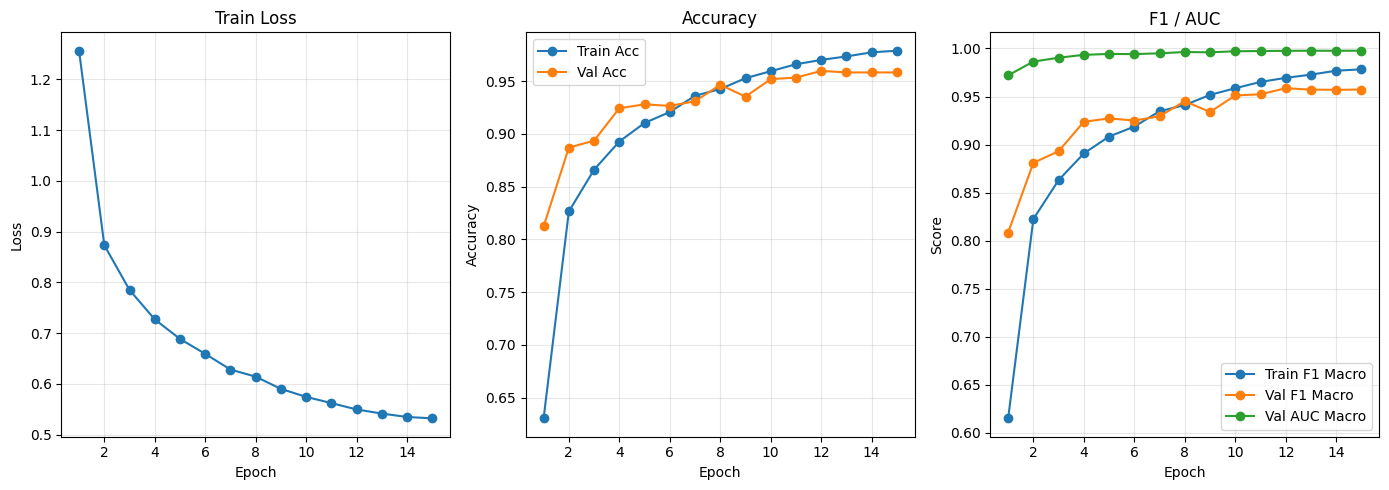

In [18]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o")
plt.title("Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(history_df["epoch"], history_df["train_acc"], marker="o", label="Train Acc")
plt.plot(history_df["epoch"], history_df["val_acc"], marker="o", label="Val Acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(history_df["epoch"], history_df["train_f1_macro"], marker="o", label="Train F1 Macro")
plt.plot(history_df["epoch"], history_df["val_f1_macro"], marker="o", label="Val F1 Macro")
plt.plot(history_df["epoch"], history_df["val_auc_macro"], marker="o", label="Val AUC Macro")
plt.title("F1 / AUC")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
ckpt = torch.load(
    "/kaggle/working/models/best_model_multiclass.pth",
    map_location=DEVICE,
    weights_only=False   # 🔥 important fix
)

model.load_state_dict(ckpt["model_state"])

print("Best model loaded.")
print(f"Best Val AUC (macro): {ckpt['val_auc_macro']:.4f}")

Best model loaded.
Best Val AUC (macro): 0.9976


### test metrics and confusion matrix

In [20]:
test_probs, test_preds, test_labels = get_predictions_and_probs(model, test_loader)

test_acc = accuracy_score(test_labels, test_preds)
test_f1_macro = f1_score(test_labels, test_preds, average="macro", zero_division=0)
test_f1_weighted = f1_score(test_labels, test_preds, average="weighted", zero_division=0)
test_auc_macro, test_auc_weighted = multiclass_auc(test_labels, test_probs, NUM_CLASSES)

test_top2 = top_k_accuracy_score(test_labels, test_probs, k=2, labels=list(range(NUM_CLASSES)))

print("=" * 70)
print("FINAL TEST RESULTS")
print("=" * 70)
print(f"Accuracy        : {test_acc*100:.2f}%")
print(f"F1 Macro        : {test_f1_macro:.4f}")
print(f"F1 Weighted     : {test_f1_weighted:.4f}")
print(f"AUC Macro (OvR) : {test_auc_macro:.4f}")
print(f"AUC Wtd  (OvR)  : {test_auc_weighted:.4f}")
print(f"Top-2 Accuracy  : {test_top2*100:.2f}%")

FINAL TEST RESULTS
Accuracy        : 95.90%
F1 Macro        : 0.9578
F1 Weighted     : 0.9593
AUC Macro (OvR) : 0.9971
AUC Wtd  (OvR)  : 0.9972
Top-2 Accuracy  : 98.73%


In [21]:
print("Classification Report:\n")
print(classification_report(
    test_labels,
    test_preds,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
))

Classification Report:

                   precision    recall  f1-score   support

DeepFakeDetection     1.0000    1.0000    1.0000       520
        Deepfakes     0.9847    0.9644    0.9745       534
        Face2Face     0.9775    0.9886    0.9830       703
      FaceShifter     0.9841    0.9686    0.9763       701
         FaceSwap     0.9783    0.9819    0.9801       552
   NeuralTextures     0.9473    0.8755    0.9099       554
         original     0.8404    0.9252    0.8808       535

         accuracy                         0.9590      4099
        macro avg     0.9589    0.9577    0.9578      4099
     weighted avg     0.9605    0.9590    0.9593      4099



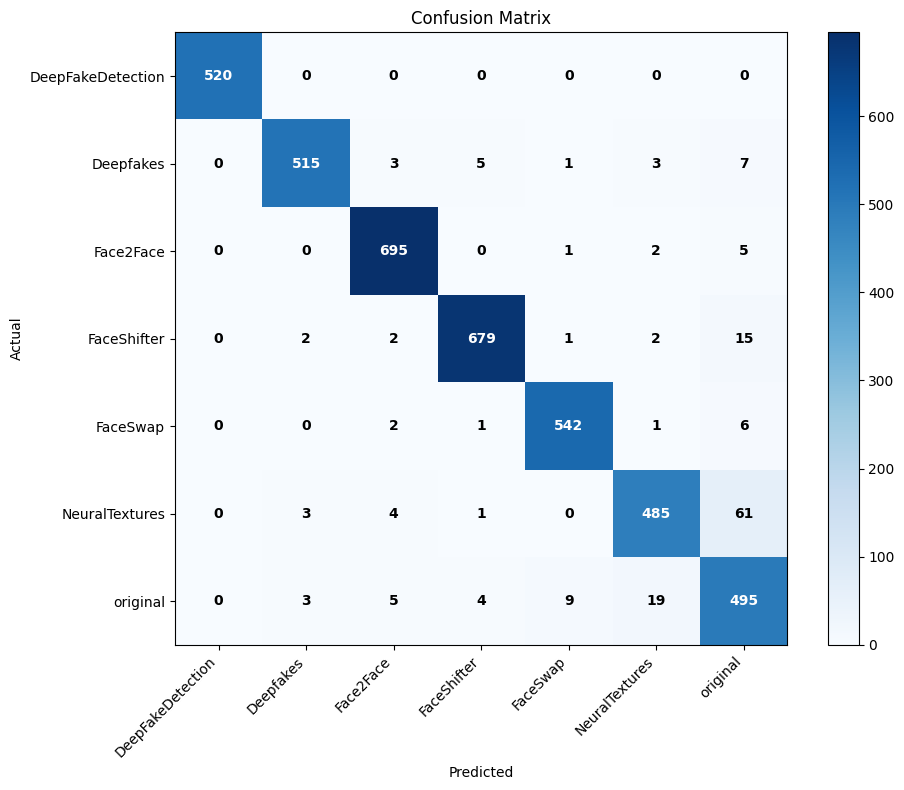

In [22]:
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45, ha="right")
plt.yticks(range(NUM_CLASSES), CLASS_NAMES)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(
            j, i, str(cm[i, j]),
            ha="center", va="center",
            color="white" if cm[i, j] > cm.max()/2 else "black",
            fontsize=10, fontweight="bold"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

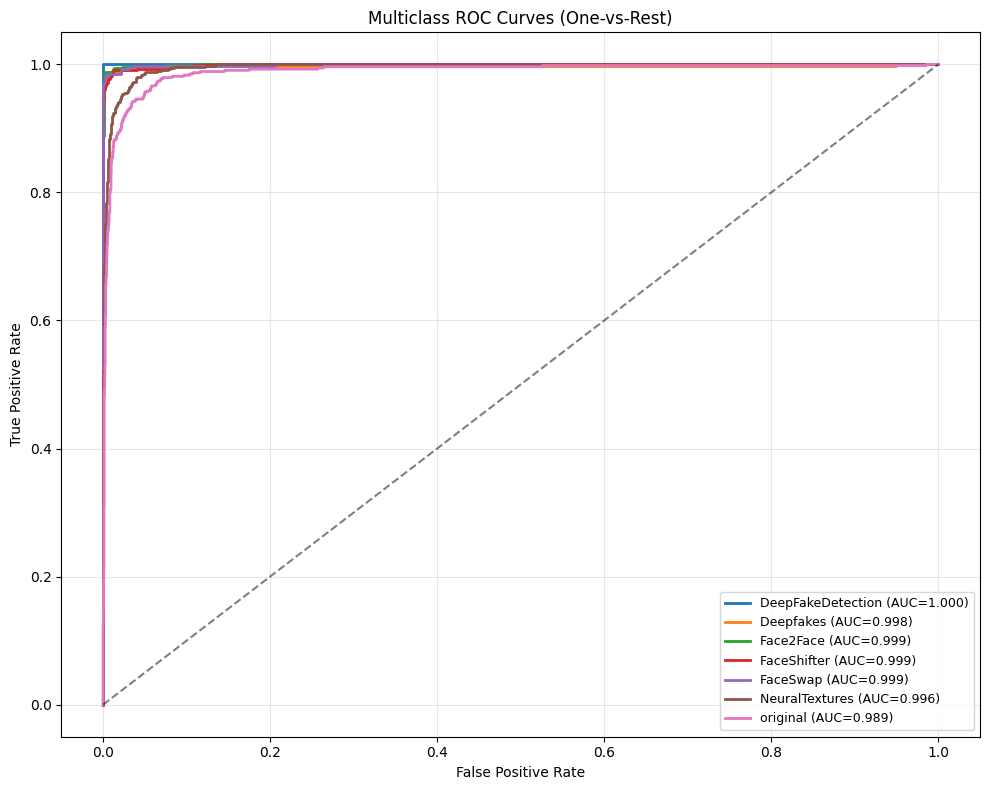

In [23]:
y_test_bin = label_binarize(test_labels, classes=list(range(NUM_CLASSES)))

plt.figure(figsize=(10, 8))

for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_probs[:, i])
    auc_i = roc_auc_score(y_test_bin[:, i], test_probs[:, i])
    plt.plot(fpr, tpr, linewidth=2, label=f"{CLASS_NAMES[i]} (AUC={auc_i:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.title("Multiclass ROC Curves (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right", fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

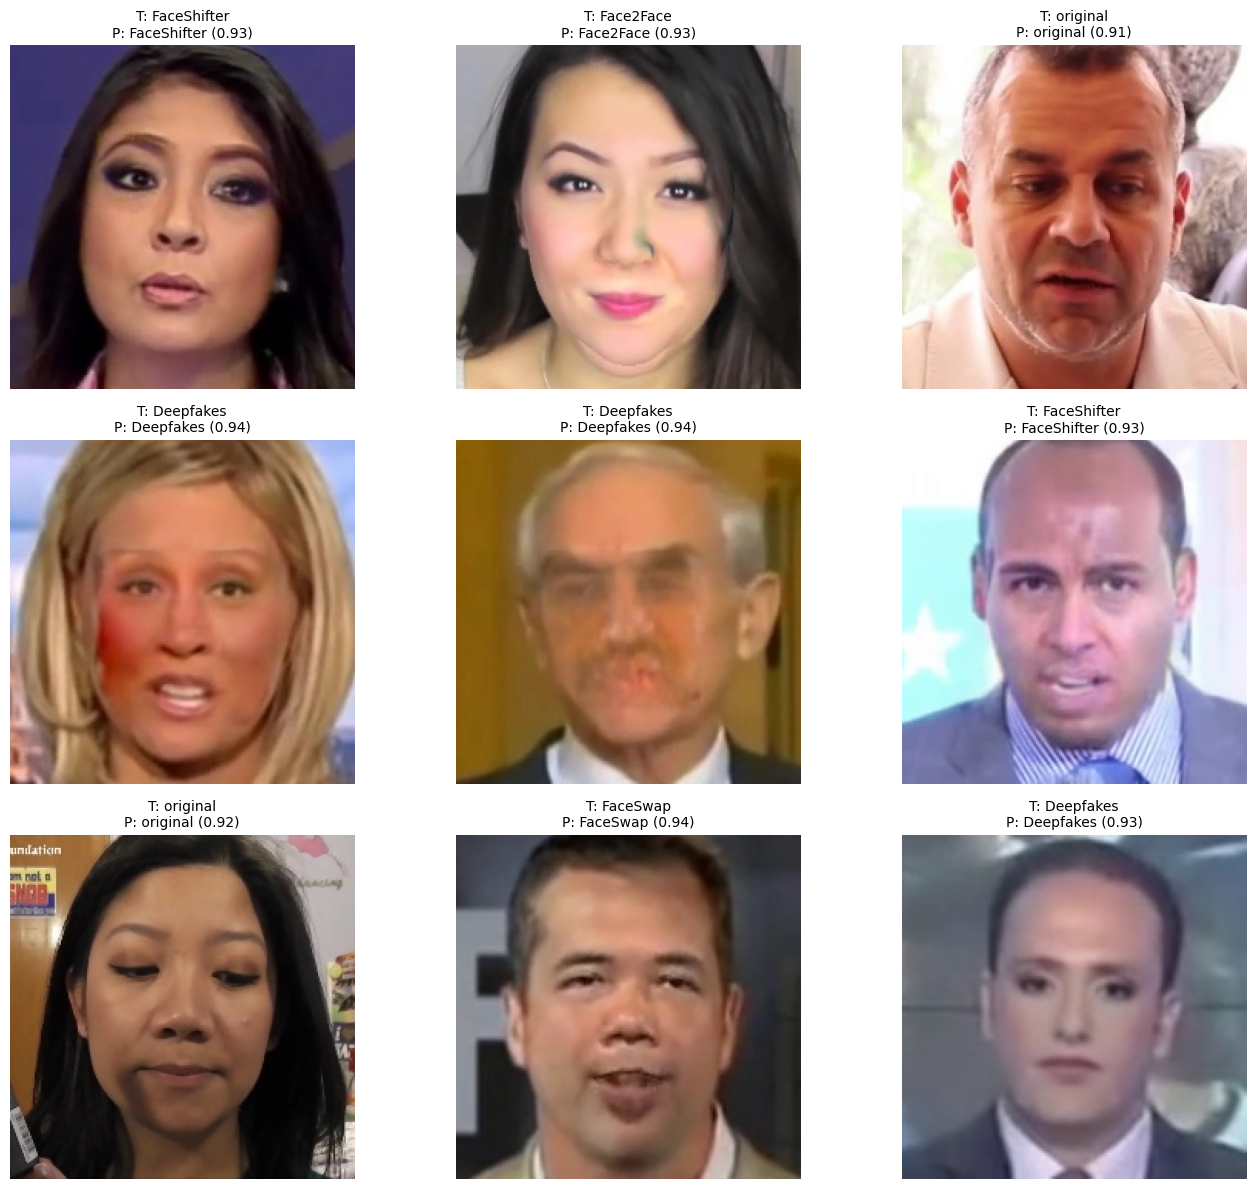

In [24]:
def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    img = torch.clamp(img, 0, 1)
    return img.permute(1, 2, 0).numpy()


model.eval()
images, labels = next(iter(test_loader))
images_gpu = images.to(DEVICE)

with torch.no_grad():
    with torch.cuda.amp.autocast():
        logits, _ = model(images_gpu)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

images = images[:9]
labels = labels[:9]
preds = preds[:9].cpu()
probs = probs[:9].cpu()

plt.figure(figsize=(14, 12))
for i in range(len(images)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(denormalize(images[i]))
    true_cls = IDX_TO_CLASS[int(labels[i])]
    pred_cls = IDX_TO_CLASS[int(preds[i])]
    conf = probs[i, preds[i]].item()
    plt.title(f"T: {true_cls}\nP: {pred_cls} ({conf:.2f})", fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [25]:
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

model.eval()

all_preds = []
all_probs = []
all_labels = []
all_weights = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        # 🔥 Model forward
        outputs, weights = model(x)   # IMPORTANT: model must return weights

        probs = torch.softmax(outputs, dim=1)

        _, preds = torch.max(outputs, dim=1)

        # Store results
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(y.cpu().numpy())
        all_weights.append(weights.cpu().numpy())

# Convert to numpy
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# 🔥 Compute mean expert weights
all_weights = np.concatenate(all_weights, axis=0)
mean_weights = all_weights.mean(axis=0)

# ------------------------
# METRICS
# ------------------------
test_acc = accuracy_score(all_labels, all_preds)

test_f1_macro = f1_score(all_labels, all_preds, average="macro")
test_f1_weighted = f1_score(all_labels, all_preds, average="weighted")

test_auc_macro = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro")
test_auc_weighted = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="weighted")

# Top-2 Accuracy
top2_preds = np.argsort(all_probs, axis=1)[:, -2:]
test_top2 = np.mean([label in top2 for label, top2 in zip(all_labels, top2_preds)])

# ------------------------
# SAVE RESULTS
# ------------------------
results = {
    "Accuracy": test_acc,
    "F1_Macro": test_f1_macro,
    "F1_Weighted": test_f1_weighted,
    "AUC_Macro_OvR": test_auc_macro,
    "AUC_Weighted_OvR": test_auc_weighted,
    "Top2_Accuracy": test_top2,
    "Texture_Weight": float(mean_weights[0]),
    "Frequency_Weight": float(mean_weights[1]),
    "Spatial_Weight": float(mean_weights[2]),
}

results_df = pd.DataFrame([results]).round(4)

# Save CSV
save_path = "/kaggle/working/final_multiclass_results.csv"
results_df.to_csv(save_path, index=False)

print(f"Saved results to {save_path}")
print(results_df.to_string(index=False))

Saved results to /kaggle/working/final_multiclass_results.csv
 Accuracy  F1_Macro  F1_Weighted  AUC_Macro_OvR  AUC_Weighted_OvR  Top2_Accuracy  Texture_Weight  Frequency_Weight  Spatial_Weight
    0.959    0.9578       0.9593         0.9971            0.9972         0.9873          0.3223            0.2371            0.17
